In [1]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip list | grep yfinance



SyntaxError: invalid syntax (862357347.py, line 1)

In [ ]:
pip list | grep yfinance

In [2]:
import numpy as np

In [3]:
import pandas as pd

In [4]:
import yfinance as yf

In [5]:
# Data download
data = yf.download("EURUSD=X", start="2022-01-01", end="2024-01-01")

# Moving averages
data["SMA20"] = data["Close"].rolling(20).mean()
data["SMA50"] = data["Close"].rolling(50).mean()

# Buy / Sell signals
data["Signal"] = np.where(data["SMA20"] > data["SMA50"], 1, -1)

# Returns
data["Market_Return"] = data["Close"].pct_change()

# Strategy returns
data["Strategy_Return"] = data["Signal"].shift(1) * data["Market_Return"]

# Cumulative profit
data["Cumulative_Return"] = (1 + data["Strategy_Return"]).cumprod()

print(data.tail())
print("Total Return:", data["Cumulative_Return"].iloc[-1])

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open   Volume     SMA20  \
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X             
Date                                                                    
2023-12-25  1.102657  1.104240  1.099989  1.102657        0  1.089489   
2023-12-26  1.102026  1.103997  1.100958  1.102026        0  1.089799   
2023-12-27  1.104301  1.112248  1.102925  1.104301        0  1.089984   
2023-12-28  1.110864  1.113945  1.107101  1.110864        0  1.090659   
2023-12-29  1.106819  1.108647  1.104326  1.106819        0  1.091539   

Price          SMA50 Signal Market_Return Strategy_Return Cumulative_Return  
Ticker                                                                       
Date                                                                         
2023-12-25  1.078230      1      0.001852        0.001852          1.180346  
2023-12-26  1.079162      1     -0.000573       -0.000573          1.179669  
2023-12-27  1.080102     

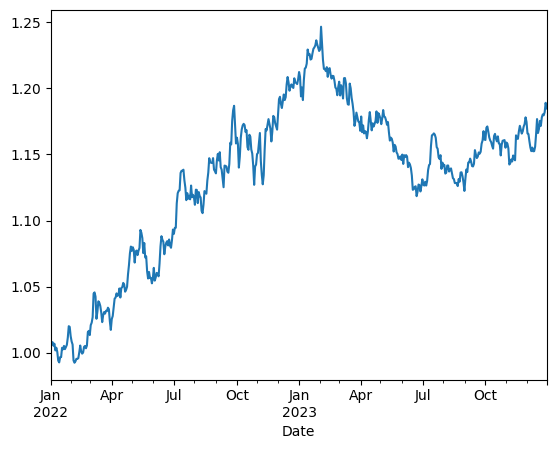

In [6]:
import matplotlib.pyplot as plt

data["Cumulative_Return"].plot()
plt.show()

In [7]:
data = yf.download("EURUSD=X", start="2020-01-01", end="2024-01-01")

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                       
2020-01-01  1.122083  1.122838  1.115947  1.122083        0
2020-01-02  1.122083  1.122712  1.116682  1.121894        0
2020-01-03  1.117144  1.118068  1.112570  1.117081        0
2020-01-06  1.116196  1.120825  1.115810  1.116246        0
2020-01-07  1.119799  1.119946  1.113487  1.119583        0


In [8]:
data["SMA50"] = data["Close"].rolling(50).mean()
data["SMA200"] = data["Close"].rolling(200).mean()

In [24]:
delta = data["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

data["RSI"] = 100 - (100 / (1 + rs))

In [25]:
data["Signal"] = 0

data.loc[(data["SMA50"] > data["SMA200"]) & (data["RSI"] < 70), "Signal"] = 1
data.loc[(data["SMA50"] < data["SMA200"]) & (data["RSI"] > 30), "Signal"] = -1

In [26]:
data["Cumulative_Return"] = (1 + data["Strategy_Return"]).cumprod()

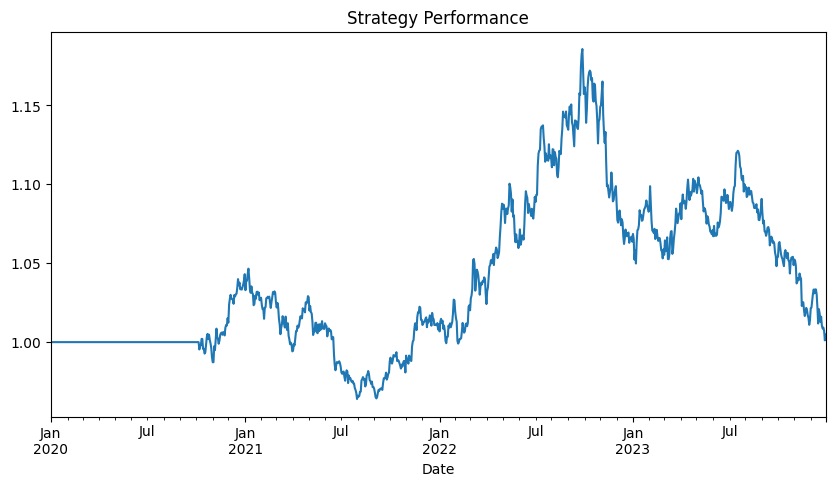

In [27]:


data["Cumulative_Return"].plot(figsize=(10,5))
plt.title("Strategy Performance")
plt.show()

In [28]:
sharpe = data["Strategy_Return"].mean() / data["Strategy_Return"].std() * (252 ** 0.5)
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.051260568161515356


In [29]:
print("Mean Return:", data["Strategy_Return"].mean())

print("Std Dev:", data["Strategy_Return"].std())

print("Total Return:", data["Cumulative_Return"].iloc[-1])

Mean Return: 1.4082361844701282e-05
Std Dev: 0.004361062935873978
Total Return: 1.004783493834413
